In [1]:
# Cell 1: Verify GPU and TensorFlow
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

2026-06-17 06:23:55.367666: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781677435.590697      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781677435.650011      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781677436.140489      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781677436.140526      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781677436.140529      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [5]:
import os

dataset_path = "/kaggle/input/pepper-bell-leaf-disease"

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        subindent = ' ' * 2 * (level + 1)
        for file in files[:3]:
            print(f'{subindent}{file}')

In [6]:
# Cell 2b: Find the exact dataset path
import os

base = "/kaggle/input"
for item in os.listdir(base):
    print(item)

datasets


In [7]:
# Cell 2c: Go deeper into the datasets folder
import os

base = "/kaggle/input/datasets"
for item in os.listdir(base):
    print(item)

kafilatmusa11


In [8]:
# Cell 2d: Go deeper into your username folder
import os

base = "/kaggle/input/datasets/kafilatmusa11"
for item in os.listdir(base):
    print(item)

pepper-bell-leaf-disease


In [9]:
# Cell 2e: Go deeper into the dataset folder
import os

base = "/kaggle/input/datasets/kafilatmusa11/pepper-bell-leaf-disease"
for item in os.listdir(base):
    print(item)

PepperBell_Leaf Curl
PepperBell_Cercospora Leaf Spot
PepperBell_Bacterial Spot
PepperBell_Powdery Mildew
PepperBell_Healthy
PepperBell_Nutrition Deficiency


In [10]:
# Cell 3: Set the main dataset path (CONFIRMED CORRECT)
dataset_path = "/kaggle/input/datasets/kafilatmusa11/pepper-bell-leaf-disease"

# List the 6 class folders to double-check
class_names = os.listdir(dataset_path)
print("Classes found:", class_names)
print("Total number of classes:", len(class_names))

Classes found: ['PepperBell_Leaf Curl', 'PepperBell_Cercospora Leaf Spot', 'PepperBell_Bacterial Spot', 'PepperBell_Powdery Mildew', 'PepperBell_Healthy', 'PepperBell_Nutrition Deficiency']
Total number of classes: 6


In [11]:
# Cell 4: Count images in each class folder
import os

dataset_path = "/kaggle/input/datasets/kafilatmusa11/pepper-bell-leaf-disease"
class_names = os.listdir(dataset_path)

print(f"{'Class Name':<35}{'Image Count'}")
print("-" * 50)

total_images = 0
class_counts = {}

for class_name in class_names:
    class_folder = os.path.join(dataset_path, class_name)
    num_images = len(os.listdir(class_folder))
    class_counts[class_name] = num_images
    total_images += num_images
    print(f"{class_name:<35}{num_images}")

print("-" * 50)
print(f"{'TOTAL':<35}{total_images}")

Class Name                         Image Count
--------------------------------------------------
PepperBell_Leaf Curl               423
PepperBell_Cercospora Leaf Spot    1796
PepperBell_Bacterial Spot          4901
PepperBell_Powdery Mildew          195
PepperBell_Healthy                 1524
PepperBell_Nutrition Deficiency    444
--------------------------------------------------
TOTAL                              9283


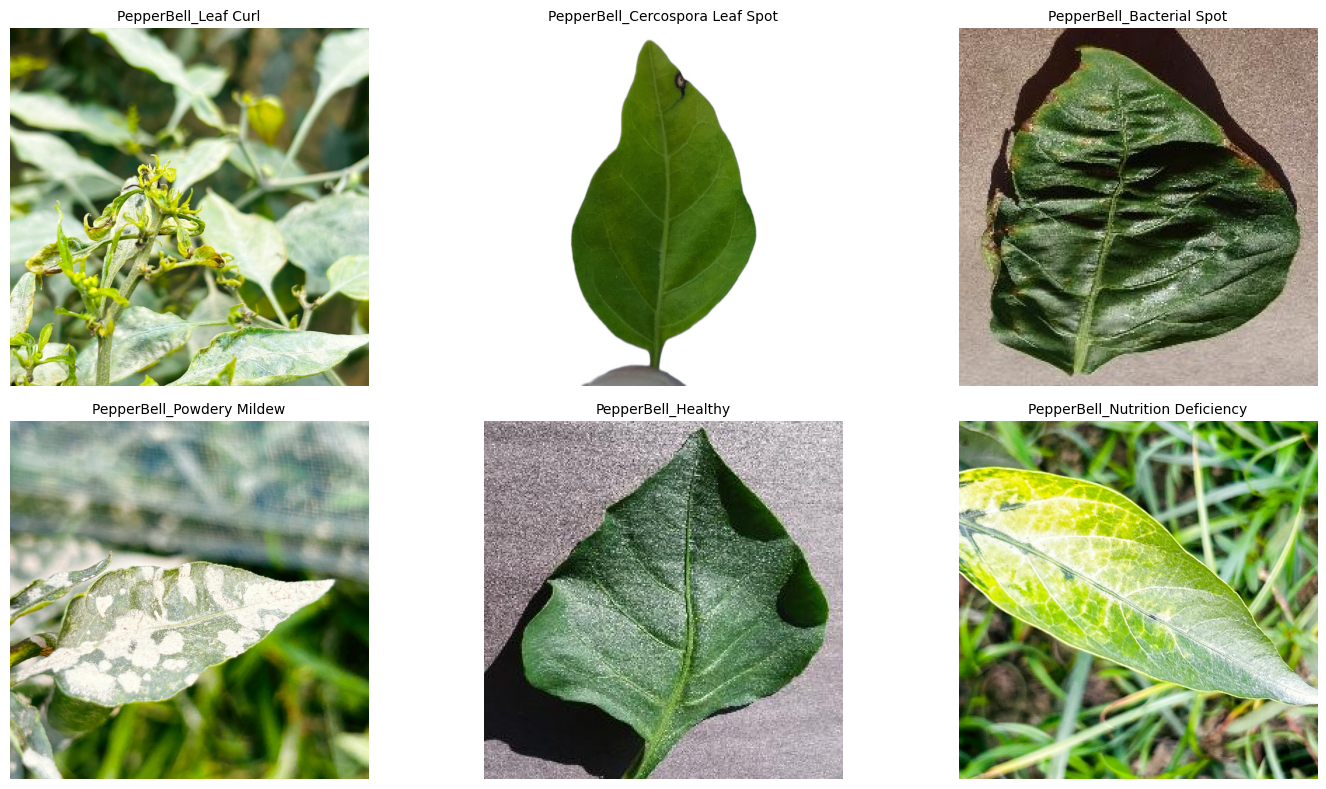

In [12]:
# Cell 5: Display one sample image from each class
import matplotlib.pyplot as plt
from PIL import Image
import os

dataset_path = "/kaggle/input/datasets/kafilatmusa11/pepper-bell-leaf-disease"
class_names = os.listdir(dataset_path)

plt.figure(figsize=(15, 8))

for i, class_name in enumerate(class_names):
    class_folder = os.path.join(dataset_path, class_name)
    sample_image_name = os.listdir(class_folder)[0]  # Get first image in folder
    image_path = os.path.join(class_folder, sample_image_name)
    
    img = Image.open(image_path)
    
    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name, fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.savefig('/kaggle/working/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Cell 6: Inspect image properties
import os
from PIL import Image

dataset_path = "/kaggle/input/datasets/kafilatmusa11/pepper-bell-leaf-disease"
class_names = os.listdir(dataset_path)

print(f"{'Class':<35}{'Sample Size':<15}{'Format':<10}{'Mode'}")
print("-" * 70)

for class_name in class_names:
    class_folder = os.path.join(dataset_path, class_name)
    sample_image_name = os.listdir(class_folder)[0]
    image_path = os.path.join(class_folder, sample_image_name)
    
    img = Image.open(image_path)
    print(f"{class_name:<35}{str(img.size):<15}{img.format:<10}{img.mode}")

Class                              Sample Size    Format    Mode
----------------------------------------------------------------------
PepperBell_Leaf Curl               (1000, 1000)   JPEG      RGB
PepperBell_Cercospora Leaf Spot    (1000, 1703)   JPEG      RGB
PepperBell_Bacterial Spot          (256, 256)     JPEG      RGB
PepperBell_Powdery Mildew          (1000, 1000)   JPEG      RGB
PepperBell_Healthy                 (256, 256)     JPEG      RGB
PepperBell_Nutrition Deficiency    (1000, 1000)   JPEG      RGB


In [14]:
# Cell 7: Install split-folders library
!pip install split-folders --quiet

In [15]:
# Cell 8: Split dataset into Train (70%), Validation (15%), Test (15%)
import splitfolders

dataset_path = "/kaggle/input/datasets/kafilatmusa11/pepper-bell-leaf-disease"
output_path = "/kaggle/working/split_data"

splitfolders.ratio(
    dataset_path,
    output=output_path,
    seed=42,           # Ensures the split is reproducible every time
    ratio=(0.7, 0.15, 0.15),  # Train, Validation, Test
    group_prefix=None
)

print("Splitting complete!")

Copying files: 9283 files [01:36, 96.49 files/s] 

Splitting complete!


In [16]:
# Cell 9: Verify the split — count images in each folder
import os

split_path = "/kaggle/working/split_data"
splits = ['train', 'val', 'test']

for split in splits:
    print(f"\n{split.upper()} SET:")
    print("-" * 50)
    split_folder = os.path.join(split_path, split)
    total = 0
    for class_name in os.listdir(split_folder):
        class_folder = os.path.join(split_folder, class_name)
        count = len(os.listdir(class_folder))
        total += count
        print(f"  {class_name:<35}{count}")
    print(f"  {'TOTAL':<35}{total}")


TRAIN SET:
--------------------------------------------------
  PepperBell_Nutrition Deficiency    310
  PepperBell_Bacterial Spot          3430
  PepperBell_Cercospora Leaf Spot    1257
  PepperBell_Powdery Mildew          136
  PepperBell_Healthy                 1066
  PepperBell_Leaf Curl               296
  TOTAL                              6495

VAL SET:
--------------------------------------------------
  PepperBell_Nutrition Deficiency    66
  PepperBell_Bacterial Spot          735
  PepperBell_Cercospora Leaf Spot    269
  PepperBell_Powdery Mildew          29
  PepperBell_Healthy                 228
  PepperBell_Leaf Curl               63
  TOTAL                              1390

TEST SET:
--------------------------------------------------
  PepperBell_Nutrition Deficiency    68
  PepperBell_Bacterial Spot          736
  PepperBell_Cercospora Leaf Spot    270
  PepperBell_Powdery Mildew          30
  PepperBell_Healthy                 230
  PepperBell_Leaf Curl             

In [17]:
# Cell 10: Set up data generators for Train, Validation, and Test
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = 224
BATCH_SIZE = 32

# Training generator — includes augmentation to handle class imbalance & overfitting
train_datagen = ImageDataGenerator(
    rescale=1./255,              # Normalize pixel values to 0-1
    rotation_range=30,            # Randomly rotate images up to 30 degrees
    width_shift_range=0.2,        # Randomly shift image horizontally
    height_shift_range=0.2,       # Randomly shift image vertically
    shear_range=0.2,               # Randomly apply shear transformation
    zoom_range=0.2,                # Randomly zoom in/out
    horizontal_flip=True,          # Randomly flip images horizontally
    fill_mode='nearest'            # Fill empty pixels created by transformations
)

# Validation and Test generators — NO augmentation (we only normalize)
# We must evaluate on real, unmodified images to get honest results
val_test_datagen = ImageDataGenerator(rescale=1./255)

print("Data generators created successfully.")

Data generators created successfully.


In [18]:
# Cell 11: Load images from folders using the generators
train_path = "/kaggle/working/split_data/train"
val_path = "/kaggle/working/split_data/val"
test_path = "/kaggle/working/split_data/test"

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=42
)

val_generator = val_test_datagen.flow_from_directory(
    val_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print("\nClass label mapping:", train_generator.class_indices)

Found 6495 images belonging to 6 classes.
Found 1390 images belonging to 6 classes.
Found 1398 images belonging to 6 classes.

Class label mapping: {'PepperBell_Bacterial Spot': 0, 'PepperBell_Cercospora Leaf Spot': 1, 'PepperBell_Healthy': 2, 'PepperBell_Leaf Curl': 3, 'PepperBell_Nutrition Deficiency': 4, 'PepperBell_Powdery Mildew': 5}


In [19]:
# Cell 12: Calculate class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get the true labels from the training generator
train_labels = train_generator.classes

# Compute weights — rare classes get higher weight, common classes get lower weight
class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert to a dictionary format Keras understands: {0: weight, 1: weight, ...}
class_weights = dict(enumerate(class_weights_array))

# Print it in a readable way alongside class names
class_names_ordered = list(train_generator.class_indices.keys())

print(f"{'Class':<35}{'Weight'}")
print("-" * 50)
for idx, weight in class_weights.items():
    print(f"{class_names_ordered[idx]:<35}{weight:.3f}")

Class                              Weight
--------------------------------------------------
PepperBell_Bacterial Spot          0.316
PepperBell_Cercospora Leaf Spot    0.861
PepperBell_Healthy                 1.015
PepperBell_Leaf Curl               3.657
PepperBell_Nutrition Deficiency    3.492
PepperBell_Powdery Mildew          7.960


In [22]:
# Cell 13: Build a simple CNN from scratch (Baseline Model)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

IMG_SIZE = 224
NUM_CLASSES = 6

cnn_model = Sequential()

# Block 1 - Detect simple features (edges, colors)
cnn_model.add(Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(2,2))

# Block 2 - Detect more complex patterns
cnn_model.add(Conv2D(64, (3,3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(2,2))

# Block 3 - Detect even more complex disease-specific patterns
cnn_model.add(Conv2D(128, (3,3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(2,2))

# Block 4 - Deepest feature extraction
cnn_model.add(Conv2D(128, (3,3), activation='relu'))
cnn_model.add(BatchNormalization())
cnn_model.add(MaxPooling2D(2,2))

# Flatten and make final decision
cnn_model.add(Flatten())
cnn_model.add(Dense(256, activation='relu'))
cnn_model.add(Dropout(0.5))
cnn_model.add(Dense(NUM_CLASSES, activation='softmax'))

cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1781679040.759116      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781679040.765016      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     4,718,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,962,630 (18.93 MB)

 Trainable params: 4,961,926 (18.93 MB)

 Non-trainable params: 704 (2.75 KB)

In [23]:
# Cell 14: Compile the model
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [24]:
# Cell 15: Set up callbacks for smarter training
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Stop training if validation loss doesn't improve for 5 epochs in a row
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Save the best version of the model automatically
checkpoint = ModelCheckpoint(
    '/kaggle/working/best_cnn_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

callbacks_list = [early_stop, checkpoint]

print("Callbacks ready.")

Callbacks ready.


In [25]:
# Cell 16: Train the CNN model
EPOCHS = 30

history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,     # Our imbalance correction from Step 8
    callbacks=callbacks_list,
    verbose=1
)

Epoch 1/30


I0000 00:00:1781679407.066260     210 service.cc:152] XLA service 0x795e60002420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781679407.066302     210 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781679407.066306     210 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781679407.754180     210 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-17 06:56:50.877555: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 06:56:51.025903: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


  2/203 ━━━━━━━━━━━━━━━━━━━━ 16s 82ms/step - accuracy: 0.1953 - loss: 5.4726     

I0000 00:00:1781679415.262085     210 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


199/203 ━━━━━━━━━━━━━━━━━━━━ 1s 420ms/step - accuracy: 0.6844 - loss: 4.8106

...

203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.6855 - loss: 4.7826

203/203 ━━━━━━━━━━━━━━━━━━━━ 110s 488ms/step - accuracy: 0.7380 - loss: 3.3655 - val_accuracy: 0.3806 - val_loss: 2.8717
Epoch 2/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.7975 - loss: 1.1258

203/203 ━━━━━━━━━━━━━━━━━━━━ 89s 436ms/step - accuracy: 0.7929 - loss: 0.9969 - val_accuracy: 0.6302 - val_loss: 0.7393
Epoch 3/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 420ms/step - accuracy: 0.8084 - loss: 0.7586

203/203 ━━━━━━━━━━━━━━━━━━━━ 90s 444ms/step - accuracy: 0.8234 - loss: 0.6566 - val_accuracy: 0.7978 - val_loss: 0.5031
Epoch 4/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 89s 439ms/step - accuracy: 0.8426 - loss: 0.7242 - val_accuracy: 0.2748 - val_loss: 19.4154
Epoch 5/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 90s 442ms/step - accuracy: 0.8146 - loss: 0.8498 - val_accuracy: 0.7799 - val_loss: 4.3775
Epoch 6/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 88s 435ms/step - accuracy: 0.8089 - loss: 0.6551 - val_accuracy: 0.1971 - val_loss: 6.8338
Epoch 7/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 89s 439ms/step - accuracy: 0.8710 - loss: 0.4330 - val_accuracy: 0.7770 - val_loss: 0.6530
Epoch 8/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.8851 - loss: 0.3272

203/203 ━━━━━━━━━━━━━━━━━━━━ 89s 439ms/step - accuracy: 0.8841 - loss: 0.3474 - val_accuracy: 0.9446 - val_loss: 0.1940
Epoch 9/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 88s 434ms/step - accuracy: 0.8864 - loss: 0.2913 - val_accuracy: 0.7712 - val_loss: 1.0604
Epoch 10/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 88s 435ms/step - accuracy: 0.9141 - loss: 0.2118 - val_accuracy: 0.7108 - val_loss: 0.7479
Epoch 11/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 89s 438ms/step - accuracy: 0.8928 - loss: 0.4153 - val_accuracy: 0.4410 - val_loss: 2.9705
Epoch 12/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 89s 437ms/step - accuracy: 0.8885 - loss: 0.4006 - val_accuracy: 0.8281 - val_loss: 2.3166
Epoch 13/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 89s 436ms/step - accuracy: 0.8902 - loss: 0.3150 - val_accuracy: 0.6511 - val_loss: 2.8114


In [26]:
# Cell 17: Check training results clearly
import numpy as np

# Find which epoch had the best validation accuracy
best_epoch = np.argmax(history_cnn.history['val_accuracy'])
best_val_acc = history_cnn.history['val_accuracy'][best_epoch]
best_val_loss = history_cnn.history['val_loss'][best_epoch]

total_epochs_run = len(history_cnn.history['val_accuracy'])

print(f"Total epochs actually run: {total_epochs_run}")
print(f"Best epoch (index starts at 0): Epoch {best_epoch + 1}")
print(f"Best validation accuracy: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"Best validation loss: {best_val_loss:.4f}")

Total epochs actually run: 13
Best epoch (index starts at 0): Epoch 8
Best validation accuracy: 0.9446 (94.46%)
Best validation loss: 0.1940


In [27]:
# Cell 18: Evaluate baseline CNN on the test set
test_loss, test_accuracy = cnn_model.evaluate(test_generator, verbose=1)

print(f"\nTest Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 6s 134ms/step - accuracy: 0.9378 - loss: 0.1937

Test Accuracy: 0.9378 (93.78%)
Test Loss: 0.1937


In [28]:
# Cell 19: Detailed classification report (Precision, Recall, F1 per class)
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get predictions
test_generator.reset()
predictions = cnn_model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# Print detailed report
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 112ms/step
                                 precision    recall  f1-score   support

      PepperBell_Bacterial Spot       0.97      0.95      0.96       736
PepperBell_Cercospora Leaf Spot       0.98      0.94      0.96       270
             PepperBell_Healthy       0.84      0.91      0.87       230
           PepperBell_Leaf Curl       0.89      1.00      0.94        64
PepperBell_Nutrition Deficiency       0.87      0.91      0.89        68
      PepperBell_Powdery Mildew       0.96      0.80      0.87        30

                       accuracy                           0.94      1398
                      macro avg       0.92      0.92      0.92      1398
                   weighted avg       0.94      0.94      0.94      1398



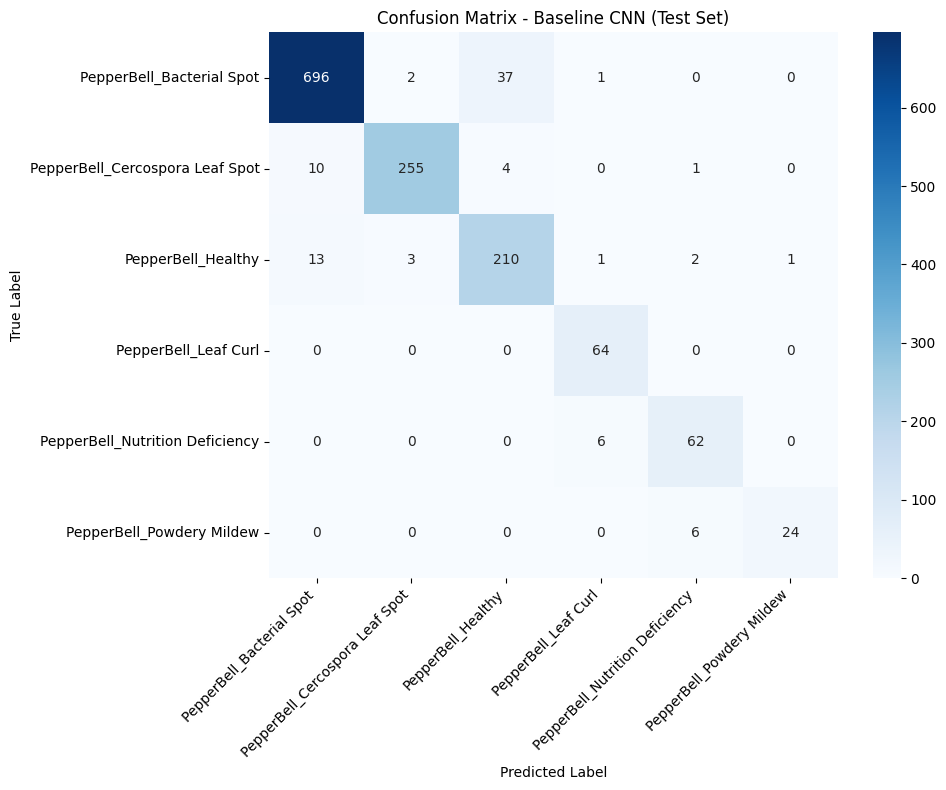

In [29]:
# Cell 20: Confusion Matrix - Baseline CNN
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Baseline CNN (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_cnn.png', dpi=150, bbox_inches='tight')
plt.show()

In [30]:
# Cell 21: Load MobileNetV2 pretrained on ImageNet
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

IMG_SIZE = 224
NUM_CLASSES = 6

# Load MobileNetV2 without its original final classification layer
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,        # We don't want its original 1000-class output layer
    weights='imagenet'        # Use weights pretrained on the ImageNet dataset
)

# Freeze the base model - don't change what it already learned (yet)
base_model.trainable = False

print("MobileNetV2 loaded. Total layers in base model:", len(base_model.layers))

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
MobileNetV2 loaded. Total layers in base model: 154


In [31]:
# Cell 22: Add custom layers on top of MobileNetV2 for our 6 classes
x = base_model.output
x = GlobalAveragePooling2D()(x)      # Condense features into a manageable size
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(NUM_CLASSES, activation='softmax')(x)

mobilenet_model = Model(inputs=base_model.input, outputs=output)

mobilenet_model.summary()

Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [32]:
# Cell 23: Compile MobileNetV2 model
mobilenet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("MobileNetV2 model compiled successfully!")

MobileNetV2 model compiled successfully!


In [33]:
# Cell 24: Set up callbacks for MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop_mb = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_mb = ModelCheckpoint(
    '/kaggle/working/best_mobilenet_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

callbacks_mb = [early_stop_mb, checkpoint_mb]

print("Callbacks ready for MobileNetV2.")

Callbacks ready for MobileNetV2.


In [34]:
# Cell 25: Train MobileNetV2
EPOCHS = 30

# Reset generators to make sure they start fresh from the beginning
train_generator.reset()
val_generator.reset()

history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks_mb,
    verbose=1
)

Epoch 1/30


2026-06-17 07:56:46.537385: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 07:56:46.674888: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


 84/203 ━━━━━━━━━━━━━━━━━━━━ 47s 401ms/step - accuracy: 0.6895 - loss: 0.8691

2026-06-17 07:57:31.724946: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 07:57:31.878715: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 07:57:32.016386: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.7900 - loss: 0.5772

...

203/203 ━━━━━━━━━━━━━━━━━━━━ 132s 565ms/step - accuracy: 0.8879 - loss: 0.2931 - val_accuracy: 0.9698 - val_loss: 0.0866
Epoch 2/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 87s 428ms/step - accuracy: 0.9555 - loss: 0.1142 - val_accuracy: 0.9590 - val_loss: 0.1270
Epoch 3/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step - accuracy: 0.9589 - loss: 0.0764

203/203 ━━━━━━━━━━━━━━━━━━━━ 88s 433ms/step - accuracy: 0.9615 - loss: 0.0816 - val_accuracy: 0.9791 - val_loss: 0.0649
Epoch 4/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 88s 432ms/step - accuracy: 0.9658 - loss: 0.0858 - val_accuracy: 0.9755 - val_loss: 0.0676
Epoch 5/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 87s 428ms/step - accuracy: 0.9720 - loss: 0.0683 - val_accuracy: 0.9719 - val_loss: 0.0817
Epoch 6/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.9674 - loss: 0.0801

203/203 ━━━━━━━━━━━━━━━━━━━━ 87s 428ms/step - accuracy: 0.9717 - loss: 0.0657 - val_accuracy: 0.9813 - val_loss: 0.0494
Epoch 7/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 86s 422ms/step - accuracy: 0.9741 - loss: 0.0559 - val_accuracy: 0.9799 - val_loss: 0.0564
Epoch 8/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 86s 424ms/step - accuracy: 0.9740 - loss: 0.0637 - val_accuracy: 0.9683 - val_loss: 0.0856
Epoch 9/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 87s 426ms/step - accuracy: 0.9794 - loss: 0.0374 - val_accuracy: 0.9799 - val_loss: 0.0734
Epoch 10/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 88s 431ms/step - accuracy: 0.9806 - loss: 0.0484 - val_accuracy: 0.9676 - val_loss: 0.0802
Epoch 11/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 86s 425ms/step - accuracy: 0.9781 - loss: 0.0500 - val_accuracy: 0.9806 - val_loss: 0.0473
Epoch 12/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 406ms/step - accuracy: 0.9779 - loss: 0.0441

203/203 ━━━━━━━━━━━━━━━━━━━━ 88s 431ms/step - accuracy: 0.9771 - loss: 0.0427 - val_accuracy: 0.9878 - val_loss: 0.0438
Epoch 13/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 88s 433ms/step - accuracy: 0.9778 - loss: 0.0546 - val_accuracy: 0.9770 - val_loss: 0.0693
Epoch 14/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 87s 430ms/step - accuracy: 0.9757 - loss: 0.0590 - val_accuracy: 0.9669 - val_loss: 0.0977
Epoch 15/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 88s 433ms/step - accuracy: 0.9738 - loss: 0.0588 - val_accuracy: 0.9849 - val_loss: 0.0367
Epoch 16/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 86s 425ms/step - accuracy: 0.9824 - loss: 0.0306 - val_accuracy: 0.9806 - val_loss: 0.0609
Epoch 17/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step - accuracy: 0.9802 - loss: 0.0370

203/203 ━━━━━━━━━━━━━━━━━━━━ 87s 429ms/step - accuracy: 0.9817 - loss: 0.0361 - val_accuracy: 0.9892 - val_loss: 0.0379
Epoch 18/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 86s 424ms/step - accuracy: 0.9828 - loss: 0.0319 - val_accuracy: 0.9863 - val_loss: 0.0427
Epoch 19/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 87s 429ms/step - accuracy: 0.9832 - loss: 0.0317 - val_accuracy: 0.9856 - val_loss: 0.0373
Epoch 20/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 86s 423ms/step - accuracy: 0.9840 - loss: 0.0271 - val_accuracy: 0.9885 - val_loss: 0.0367
Epoch 21/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 87s 429ms/step - accuracy: 0.9758 - loss: 0.0635 - val_accuracy: 0.9835 - val_loss: 0.0445
Epoch 22/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 85s 421ms/step - accuracy: 0.9821 - loss: 0.0515 - val_accuracy: 0.9856 - val_loss: 0.0409
Epoch 23/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 87s 428ms/step - accuracy: 0.9808 - loss: 0.0684 - val_accuracy: 0.9871 - val_loss: 0.0439
Epoch 24/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 87s 427ms/step - accuracy: 0.9800 - loss: 0.042

In [35]:
# Cell 26: Check MobileNetV2 training results
import numpy as np

best_epoch_mb = np.argmax(history_mobilenet.history['val_accuracy'])
best_val_acc_mb = history_mobilenet.history['val_accuracy'][best_epoch_mb]
best_val_loss_mb = history_mobilenet.history['val_loss'][best_epoch_mb]
total_epochs_mb = len(history_mobilenet.history['val_accuracy'])

print(f"Total epochs run: {total_epochs_mb}")
print(f"Best epoch: {best_epoch_mb + 1}")
print(f"Best validation accuracy: {best_val_acc_mb:.4f} ({best_val_acc_mb*100:.2f}%)")
print(f"Best validation loss: {best_val_loss_mb:.4f}")

Total epochs run: 25
Best epoch: 17
Best validation accuracy: 0.9892 (98.92%)
Best validation loss: 0.0379


In [36]:
# Cell 27: Evaluate MobileNetV2 on the test set
test_generator.reset()
test_loss_mb, test_accuracy_mb = mobilenet_model.evaluate(test_generator, verbose=1)

print(f"\nTest Accuracy: {test_accuracy_mb:.4f} ({test_accuracy_mb*100:.2f}%)")
print(f"Test Loss: {test_loss_mb:.4f}")

43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step - accuracy: 0.9825 - loss: 0.0456

2026-06-17 08:39:36.561357: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 08:39:36.712867: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-17 08:39:36.849777: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


44/44 ━━━━━━━━━━━━━━━━━━━━ 15s 346ms/step - accuracy: 0.9850 - loss: 0.0462

Test Accuracy: 0.9850 (98.50%)
Test Loss: 0.0462


In [37]:
# Cell 28: Detailed classification report for MobileNetV2
from sklearn.metrics import classification_report
import numpy as np

test_generator.reset()
predictions_mb = mobilenet_model.predict(test_generator, verbose=1)
predicted_classes_mb = np.argmax(predictions_mb, axis=1)
true_classes_mb = test_generator.classes
class_labels_mb = list(test_generator.class_indices.keys())

print(classification_report(true_classes_mb, predicted_classes_mb, target_names=class_labels_mb))

44/44 ━━━━━━━━━━━━━━━━━━━━ 13s 199ms/step
                                 precision    recall  f1-score   support

      PepperBell_Bacterial Spot       0.99      0.99      0.99       736
PepperBell_Cercospora Leaf Spot       0.98      0.99      0.98       270
             PepperBell_Healthy       0.98      0.97      0.98       230
           PepperBell_Leaf Curl       1.00      1.00      1.00        64
PepperBell_Nutrition Deficiency       0.97      1.00      0.99        68
      PepperBell_Powdery Mildew       1.00      1.00      1.00        30

                       accuracy                           0.98      1398
                      macro avg       0.99      0.99      0.99      1398
                   weighted avg       0.98      0.98      0.98      1398



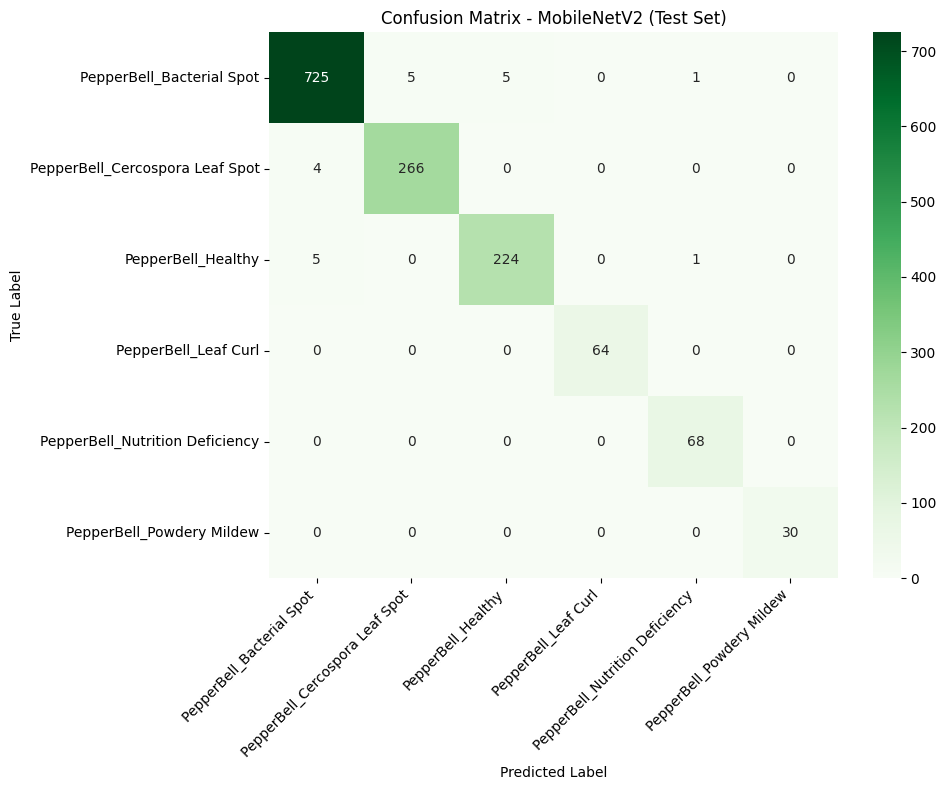

In [38]:
# Cell 29: Confusion Matrix - MobileNetV2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_mb = confusion_matrix(true_classes_mb, predicted_classes_mb)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_mb, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_labels_mb, yticklabels=class_labels_mb)
plt.title('Confusion Matrix - MobileNetV2 (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_mobilenet.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Cell 30: Load ResNet50V2 pretrained on ImageNet
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

IMG_SIZE = 224
NUM_CLASSES = 6

base_model_resnet = ResNet50V2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model initially, just like we did for MobileNetV2
base_model_resnet.trainable = False

print("ResNet50V2 loaded. Total layers in base model:", len(base_model_resnet.layers))

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
ResNet50V2 loaded. Total layers in base model: 190


In [40]:
# Cell 31: Add custom layers on top of ResNet50V2
x = base_model_resnet.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output_resnet = Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = Model(inputs=base_model_resnet.input, outputs=output_resnet)

resnet_model.summary()

Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_2[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_conv[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │        256 │ pool1_pool[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_preac… │ (None, 56, 56,    │          0 │ conv2_block1_pre… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,096 │ conv2_block1_pre… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_pad  │ (None, 58, 58,    │          0 │ conv2_block1_1_r… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_2_p… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_pre… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_out    │ (None, 56, 56,    │          0 │ conv2_block1_0_c

 Total params: 23,827,846 (90.90 MB)

 Trainable params: 263,046 (1.00 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [41]:
# Cell 32: Compile ResNet50V2 model
resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("ResNet50V2 model compiled successfully!")

ResNet50V2 model compiled successfully!


In [42]:
# Cell 33: Set up callbacks for ResNet50V2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop_resnet = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_resnet = ModelCheckpoint(
    '/kaggle/working/best_resnet_model.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

callbacks_resnet = [early_stop_resnet, checkpoint_resnet]

print("Callbacks ready for ResNet50V2.")

Callbacks ready for ResNet50V2.


In [43]:
# Cell 34: Train ResNet50V2
EPOCHS = 30

train_generator.reset()
val_generator.reset()

history_resnet = resnet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks_resnet,
    verbose=1
)

Epoch 1/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.8218 - loss: 0.5267

203/203 ━━━━━━━━━━━━━━━━━━━━ 116s 508ms/step - accuracy: 0.8908 - loss: 0.3040 - val_accuracy: 0.9424 - val_loss: 0.1533
Epoch 2/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9491 - loss: 0.1059

203/203 ━━━━━━━━━━━━━━━━━━━━ 91s 447ms/step - accuracy: 0.9532 - loss: 0.1000 - val_accuracy: 0.9741 - val_loss: 0.0818
Epoch 3/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 89s 436ms/step - accuracy: 0.9590 - loss: 0.0996 - val_accuracy: 0.9734 - val_loss: 0.0746
Epoch 4/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 407ms/step - accuracy: 0.9652 - loss: 0.0706

203/203 ━━━━━━━━━━━━━━━━━━━━ 89s 437ms/step - accuracy: 0.9678 - loss: 0.0726 - val_accuracy: 0.9755 - val_loss: 0.0670
Epoch 5/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 88s 435ms/step - accuracy: 0.9701 - loss: 0.0582 - val_accuracy: 0.9568 - val_loss: 0.1255
Epoch 6/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.9608 - loss: 0.0899

203/203 ━━━━━━━━━━━━━━━━━━━━ 89s 438ms/step - accuracy: 0.9635 - loss: 0.0991 - val_accuracy: 0.9770 - val_loss: 0.0678
Epoch 7/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 89s 436ms/step - accuracy: 0.9727 - loss: 0.0584 - val_accuracy: 0.9755 - val_loss: 0.0716
Epoch 8/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 409ms/step - accuracy: 0.9746 - loss: 0.0427

203/203 ━━━━━━━━━━━━━━━━━━━━ 89s 439ms/step - accuracy: 0.9760 - loss: 0.0444 - val_accuracy: 0.9842 - val_loss: 0.0529
Epoch 9/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 90s 441ms/step - accuracy: 0.9769 - loss: 0.0475 - val_accuracy: 0.9748 - val_loss: 0.0742
Epoch 10/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 89s 436ms/step - accuracy: 0.9692 - loss: 0.0773 - val_accuracy: 0.9727 - val_loss: 0.0820
Epoch 11/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.9722 - loss: 0.0633

203/203 ━━━━━━━━━━━━━━━━━━━━ 90s 444ms/step - accuracy: 0.9721 - loss: 0.0607 - val_accuracy: 0.9863 - val_loss: 0.0438
Epoch 12/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 89s 438ms/step - accuracy: 0.9783 - loss: 0.0421 - val_accuracy: 0.9842 - val_loss: 0.0573
Epoch 13/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9764 - loss: 0.0380

203/203 ━━━━━━━━━━━━━━━━━━━━ 90s 441ms/step - accuracy: 0.9789 - loss: 0.0333 - val_accuracy: 0.9871 - val_loss: 0.0487
Epoch 14/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 89s 437ms/step - accuracy: 0.9763 - loss: 0.0665 - val_accuracy: 0.9813 - val_loss: 0.0525
Epoch 15/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.9805 - loss: 0.0338

203/203 ━━━━━━━━━━━━━━━━━━━━ 91s 446ms/step - accuracy: 0.9801 - loss: 0.0360 - val_accuracy: 0.9892 - val_loss: 0.0417
Epoch 16/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 90s 441ms/step - accuracy: 0.9781 - loss: 0.0404 - val_accuracy: 0.9871 - val_loss: 0.0419
Epoch 17/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 89s 436ms/step - accuracy: 0.9798 - loss: 0.0334 - val_accuracy: 0.9791 - val_loss: 0.0567
Epoch 18/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 90s 443ms/step - accuracy: 0.9824 - loss: 0.0359 - val_accuracy: 0.9835 - val_loss: 0.0547
Epoch 19/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 90s 443ms/step - accuracy: 0.9780 - loss: 0.0504 - val_accuracy: 0.9835 - val_loss: 0.0544
Epoch 20/30
203/203 ━━━━━━━━━━━━━━━━━━━━ 90s 442ms/step - accuracy: 0.9801 - loss: 0.0506 - val_accuracy: 0.9820 - val_loss: 0.0529


In [44]:
# Cell 35: Check ResNet50V2 training results
import numpy as np

best_epoch_resnet = np.argmax(history_resnet.history['val_accuracy'])
best_val_acc_resnet = history_resnet.history['val_accuracy'][best_epoch_resnet]
best_val_loss_resnet = history_resnet.history['val_loss'][best_epoch_resnet]
total_epochs_resnet = len(history_resnet.history['val_accuracy'])

print(f"Total epochs run: {total_epochs_resnet}")
print(f"Best epoch: {best_epoch_resnet + 1}")
print(f"Best validation accuracy: {best_val_acc_resnet:.4f} ({best_val_acc_resnet*100:.2f}%)")
print(f"Best validation loss: {best_val_loss_resnet:.4f}")

Total epochs run: 20
Best epoch: 15
Best validation accuracy: 0.9892 (98.92%)
Best validation loss: 0.0417


In [45]:
# Cell 36: Evaluate ResNet50V2 on the test set
test_generator.reset()
test_loss_resnet, test_accuracy_resnet = resnet_model.evaluate(test_generator, verbose=1)

print(f"\nTest Accuracy: {test_accuracy_resnet:.4f} ({test_accuracy_resnet*100:.2f}%)")
print(f"Test Loss: {test_loss_resnet:.4f}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 229ms/step - accuracy: 0.9843 - loss: 0.0550

Test Accuracy: 0.9843 (98.43%)
Test Loss: 0.0550


In [46]:
# Cell 37: Detailed classification report for ResNet50V2
from sklearn.metrics import classification_report
import numpy as np

test_generator.reset()
predictions_resnet = resnet_model.predict(test_generator, verbose=1)
predicted_classes_resnet = np.argmax(predictions_resnet, axis=1)
true_classes_resnet = test_generator.classes
class_labels_resnet = list(test_generator.class_indices.keys())

print(classification_report(true_classes_resnet, predicted_classes_resnet, target_names=class_labels_resnet))

44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 193ms/step
                                 precision    recall  f1-score   support

      PepperBell_Bacterial Spot       0.99      0.98      0.99       736
PepperBell_Cercospora Leaf Spot       0.99      0.98      0.98       270
             PepperBell_Healthy       0.96      0.99      0.97       230
           PepperBell_Leaf Curl       1.00      1.00      1.00        64
PepperBell_Nutrition Deficiency       0.99      1.00      0.99        68
      PepperBell_Powdery Mildew       1.00      1.00      1.00        30

                       accuracy                           0.98      1398
                      macro avg       0.99      0.99      0.99      1398
                   weighted avg       0.98      0.98      0.98      1398



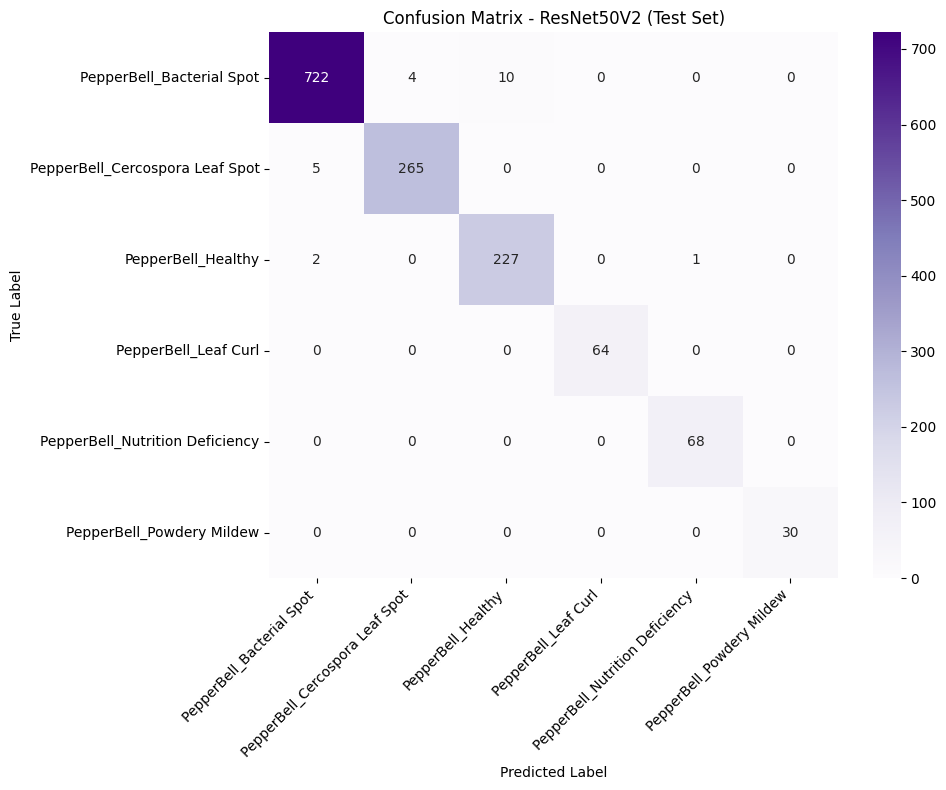

In [47]:
# Cell 38: Confusion Matrix - ResNet50V2
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm_resnet = confusion_matrix(true_classes_resnet, predicted_classes_resnet)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_resnet, annot=True, fmt='d', cmap='Purples',
            xticklabels=class_labels_resnet, yticklabels=class_labels_resnet)
plt.title('Confusion Matrix - ResNet50V2 (Test Set)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix_resnet.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
# Cell 39: Unfreeze the last 20 layers of MobileNetV2 for fine-tuning
base_model.trainable = True

# Freeze everything except the last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

trainable_layer_count = sum([1 for layer in base_model.layers if layer.trainable])
print(f"Layers now trainable in base model: {trainable_layer_count} out of {len(base_model.layers)}")

Layers now trainable in base model: 20 out of 154


In [49]:
# Cell 40: Recompile with a smaller learning rate for fine-tuning
from tensorflow.keras.optimizers import Adam

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.00001),   # 100x smaller than the original 0.001
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model recompiled for fine-tuning with learning rate = 0.00001")

Model recompiled for fine-tuning with learning rate = 0.00001


In [50]:
# Cell 40: Recompile with a smaller learning rate for fine-tuning
from tensorflow.keras.optimizers import Adam

mobilenet_model.compile(
    optimizer=Adam(learning_rate=0.00001),   # 100x smaller than the original 0.001
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model recompiled for fine-tuning with learning rate = 0.00001")

Model recompiled for fine-tuning with learning rate = 0.00001


In [51]:
# Cell 41: Set up fresh callbacks for fine-tuning phase
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop_ft = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_ft = ModelCheckpoint(
    '/kaggle/working/best_mobilenet_finetuned.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

callbacks_ft = [early_stop_ft, checkpoint_ft]

EPOCHS_FT = 15

train_generator.reset()
val_generator.reset()

history_finetune = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_FT,
    class_weight=class_weights,
    callbacks=callbacks_ft,
    verbose=1
)

Epoch 1/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.8060 - loss: 0.4475

203/203 ━━━━━━━━━━━━━━━━━━━━ 116s 503ms/step - accuracy: 0.8605 - loss: 0.2571 - val_accuracy: 0.9727 - val_loss: 0.0769
Epoch 2/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 87s 428ms/step - accuracy: 0.9341 - loss: 0.1040 - val_accuracy: 0.9504 - val_loss: 0.1639
Epoch 3/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 86s 425ms/step - accuracy: 0.9578 - loss: 0.0670 - val_accuracy: 0.9475 - val_loss: 0.1721
Epoch 4/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 87s 429ms/step - accuracy: 0.9661 - loss: 0.0619 - val_accuracy: 0.9281 - val_loss: 0.2440
Epoch 5/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 87s 428ms/step - accuracy: 0.9706 - loss: 0.0503 - val_accuracy: 0.9475 - val_loss: 0.1634
Epoch 6/15
203/203 ━━━━━━━━━━━━━━━━━━━━ 86s 423ms/step - accuracy: 0.9732 - loss: 0.0463 - val_accuracy: 0.9489 - val_loss: 0.1577


In [52]:
# Cell 42: Check fine-tuning results
import numpy as np

best_epoch_ft = np.argmax(history_finetune.history['val_accuracy'])
best_val_acc_ft = history_finetune.history['val_accuracy'][best_epoch_ft]
best_val_loss_ft = history_finetune.history['val_loss'][best_epoch_ft]
total_epochs_ft = len(history_finetune.history['val_accuracy'])

print(f"Total epochs run: {total_epochs_ft}")
print(f"Best epoch: {best_epoch_ft + 1}")
print(f"Best validation accuracy: {best_val_acc_ft:.4f} ({best_val_acc_ft*100:.2f}%)")
print(f"Best validation loss: {best_val_loss_ft:.4f}")

Total epochs run: 6
Best epoch: 1
Best validation accuracy: 0.9727 (97.27%)
Best validation loss: 0.0769


In [53]:
# Cell 43: Evaluate fine-tuned MobileNetV2 on the test set
test_generator.reset()
test_loss_ft, test_accuracy_ft = mobilenet_model.evaluate(test_generator, verbose=1)

print(f"\nTest Accuracy (Fine-tuned): {test_accuracy_ft:.4f} ({test_accuracy_ft*100:.2f}%)")
print(f"Test Loss (Fine-tuned): {test_loss_ft:.4f}")

44/44 ━━━━━━━━━━━━━━━━━━━━ 8s 177ms/step - accuracy: 0.9700 - loss: 0.0955

Test Accuracy (Fine-tuned): 0.9700 (97.00%)
Test Loss (Fine-tuned): 0.0955
